## 1.SYNTHETIC DATASET GENERATION

In [1]:
import random
import csv

services = [
    "Mobile Network",
    "Broadband Service",
    "Billing & Payments",
    "Customer Support",
    "Mobile App Issues",
    "Service Activation"
]

positive_templates = [
    "The {service} is excellent and working perfectly",
    "Really happy with the {service}",
    "{service} has improved a lot recently",
    "Great experience using {service}",
    "{service} is fast and reliable"
]

negative_templates = [
    "The {service} is very poor and disappointing",
    "Facing constant issues with {service}",
    "{service} is extremely unreliable",
    "Very bad experience with {service}",
    "{service} needs serious improvement"
]

neutral_templates = [
    "{service} is okay but nothing special",
    "Average experience with {service}",
    "{service} works fine sometimes",
    "No major issues but could be better in {service}",
    "{service} is acceptable for now"
]

mixed_templates = [
    "The {service} is good but has some issues",
    "I like the {service} but it needs improvement",
    "{service} works well sometimes but fails often",
    "There are both good and bad aspects of {service}",
    "{service} is fast but frequently disconnects"
]

def generate_feedback(templates, sentiment, count):
    data = []
    for _ in range(count):
        service = random.choice(services)
        template = random.choice(templates)
        feedback = template.format(service=service)
        data.append([feedback, sentiment, service])
    return data

dataset = []

dataset += generate_feedback(positive_templates, "Positive", 3000)
dataset += generate_feedback(negative_templates, "Negative", 3000)
dataset += generate_feedback(neutral_templates, "Neutral", 3000)
dataset += generate_feedback(mixed_templates, "Mixed", 1000)

random.shuffle(dataset)

with open("telecom_feedback_dataset.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["feedback", "sentiment", "service_category"])
    writer.writerows(dataset)

print("✅ Dataset with 10,000 rows generated!")

✅ Dataset with 10,000 rows generated!


In [2]:
import pandas as pd

df = pd.read_csv("telecom_feedback_dataset.csv")

print(df.head())
print(df['sentiment'].value_counts())
print(df['service_category'].value_counts())

                                            feedback sentiment  \
0  The Billing & Payments is excellent and workin...  Positive   
1          Average experience with Broadband Service   Neutral   
2  The Customer Support is excellent and working ...  Positive   
3      Broadband Service is okay but nothing special   Neutral   
4  No major issues but could be better in Mobile ...   Neutral   

     service_category  
0  Billing & Payments  
1   Broadband Service  
2    Customer Support  
3   Broadband Service  
4   Mobile App Issues  
sentiment
Positive    3000
Neutral     3000
Negative    3000
Mixed       1000
Name: count, dtype: int64
service_category
Billing & Payments    1695
Broadband Service     1685
Mobile App Issues     1685
Service Activation    1654
Mobile Network        1641
Customer Support      1640
Name: count, dtype: int64


## 2.EDA

### Sentiment Distribution

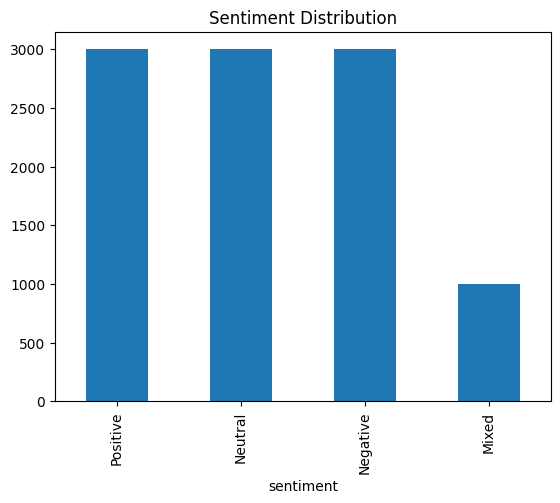

In [3]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

### Service Category Distribution

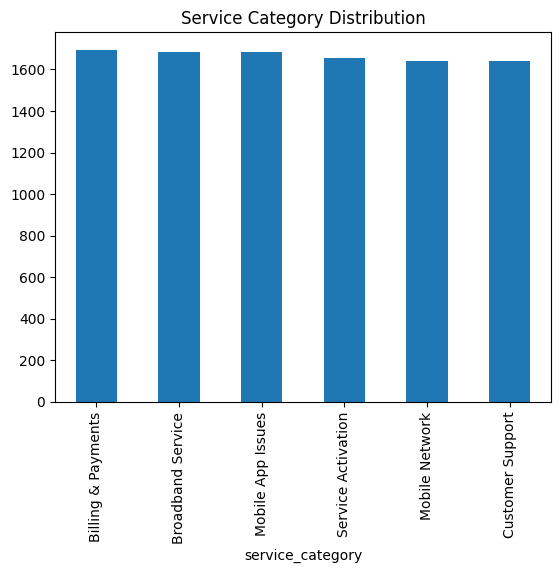

In [4]:
df['service_category'].value_counts().plot(kind='bar')
plt.title("Service Category Distribution")
plt.show()

### Sentiment vs Category

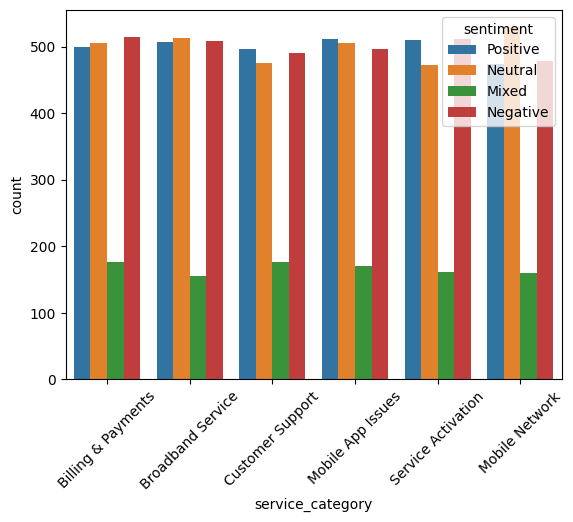

In [5]:
import seaborn as sns

sns.countplot(data=df, x='service_category', hue='sentiment')
plt.xticks(rotation=45)
plt.show()

### Message Length Analysis

In [10]:
print(df.columns)

Index(['feedback', 'sentiment', 'service_category'], dtype='object')


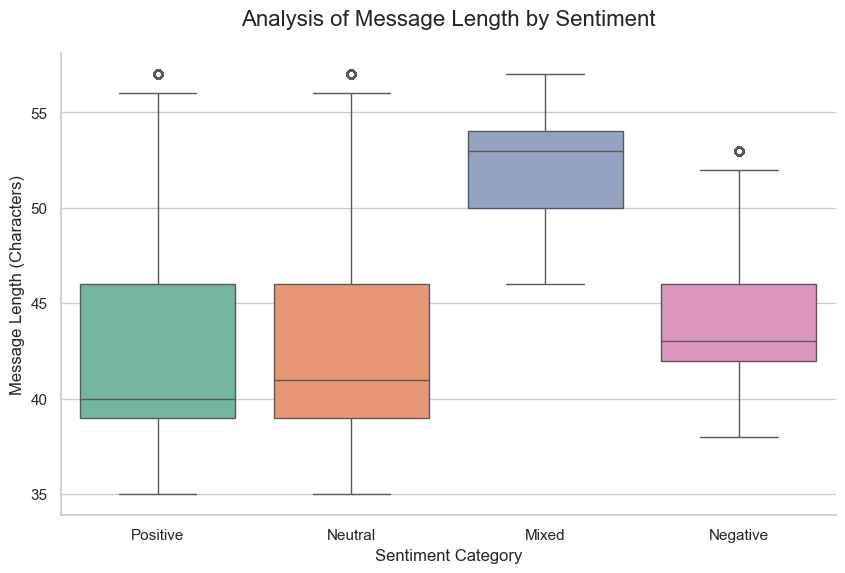

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the new 'length' column 
# This counts the number of characters in each 'feedback' message
df['length'] = df['feedback'].astype(str).str.len()

# 2. Set a professional style
sns.set_theme(style="whitegrid")

# 3. Create the figure
plt.figure(figsize=(10, 6))

# 4. Plot the boxplot (now it will work because 'length' exists!)
ax = sns.boxplot(data=df, x='sentiment', y='length', palette='Set2', hue='sentiment', legend=False)

# 5. Add titles and labels
plt.title('Analysis of Message Length by Sentiment', fontsize=16, pad=20)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Message Length (Characters)', fontsize=12)

# 6. Remove the top and right spines for a cleaner look
sns.despine()

# 7. Show the plot
plt.show()

Mixed Sentiment stands out: Messages categorized as "Mixed" are significantly longer than the others. The entire "box" for Mixed sentiment sits higher than the medians of the other three categories. This suggests that users expressing complex or conflicting emotions tend to use more words to explain themselves.

Consistency across Positive, Negative, and Neutral: These three categories share a very similar range. Their "boxes" (representing the middle 50% of the data) mostly overlap between a length of 39 and 46.

Negative messages are more "compact": The box for Negative sentiment is slightly smaller and has a higher median than Positive or Neutral. This indicates that negative feedback in your dataset is consistently mid-length, whereas Positive and Neutral messages have more variation.

## Multivariate Analysis:

### Message length vs sentiment vs topic

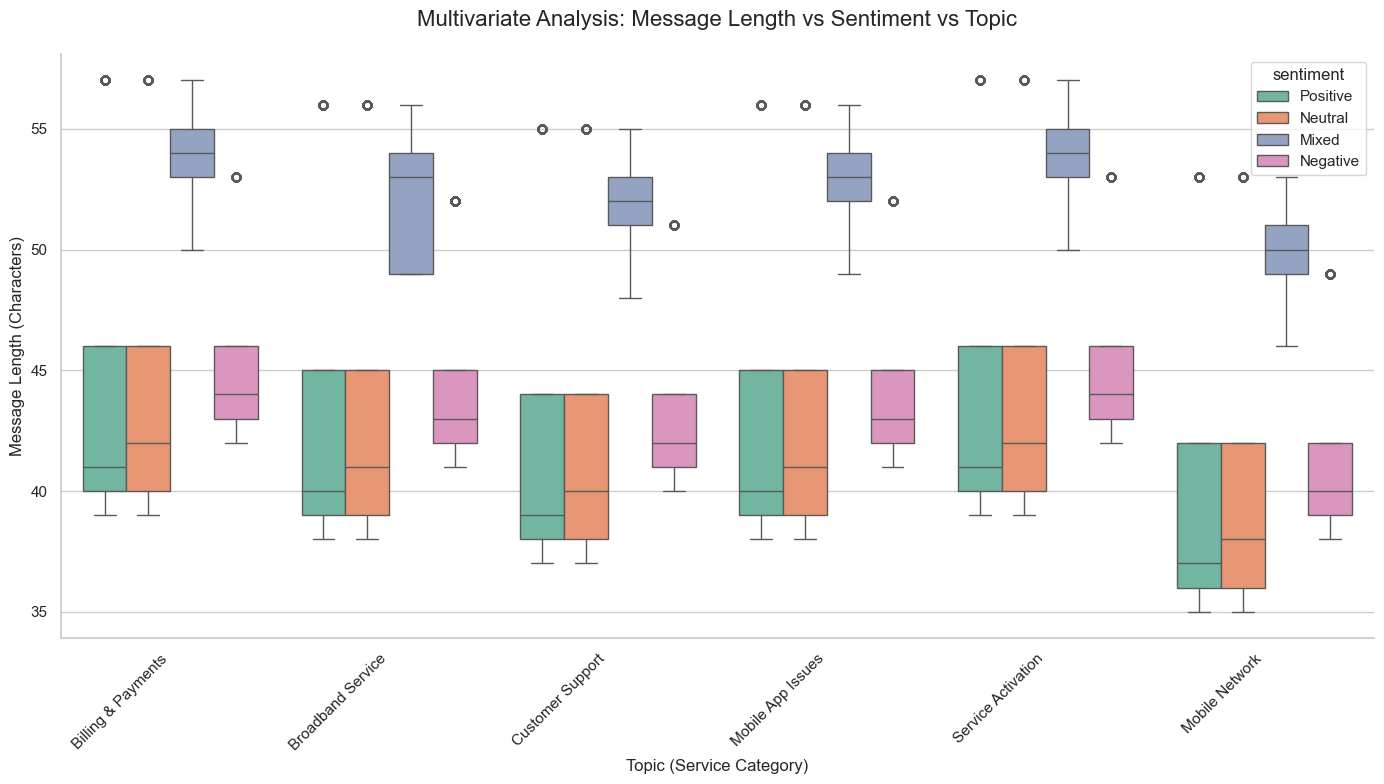

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('telecom_feedback_dataset.csv')

# 2. Create the 'length' column
df['length'] = df['feedback'].astype(str).str.len()

# 3. Set a clean visual style
sns.set_theme(style="whitegrid")

# 4. Create the figure (made it a bit wider to fit the topics)
plt.figure(figsize=(14, 8))

# 5. Plot the MULTIVARIATE boxplot
# x = Topic, y = Length, hue = Sentiment (color)
ax = sns.boxplot(
    data=df, 
    x='service_category', 
    y='length', 
    hue='sentiment', 
    palette='Set2'
)

# 6. Add titles and labels
plt.title('Multivariate Analysis: Message Length vs Sentiment vs Topic', fontsize=16, pad=20)
plt.xlabel('Topic (Service Category)', fontsize=12)
plt.ylabel('Message Length (Characters)', fontsize=12)

# 7. Rotate the topic names on the x-axis so they are readable
plt.xticks(rotation=45, ha='right')

# 8. Clean up and show
sns.despine()
plt.tight_layout()
plt.show()

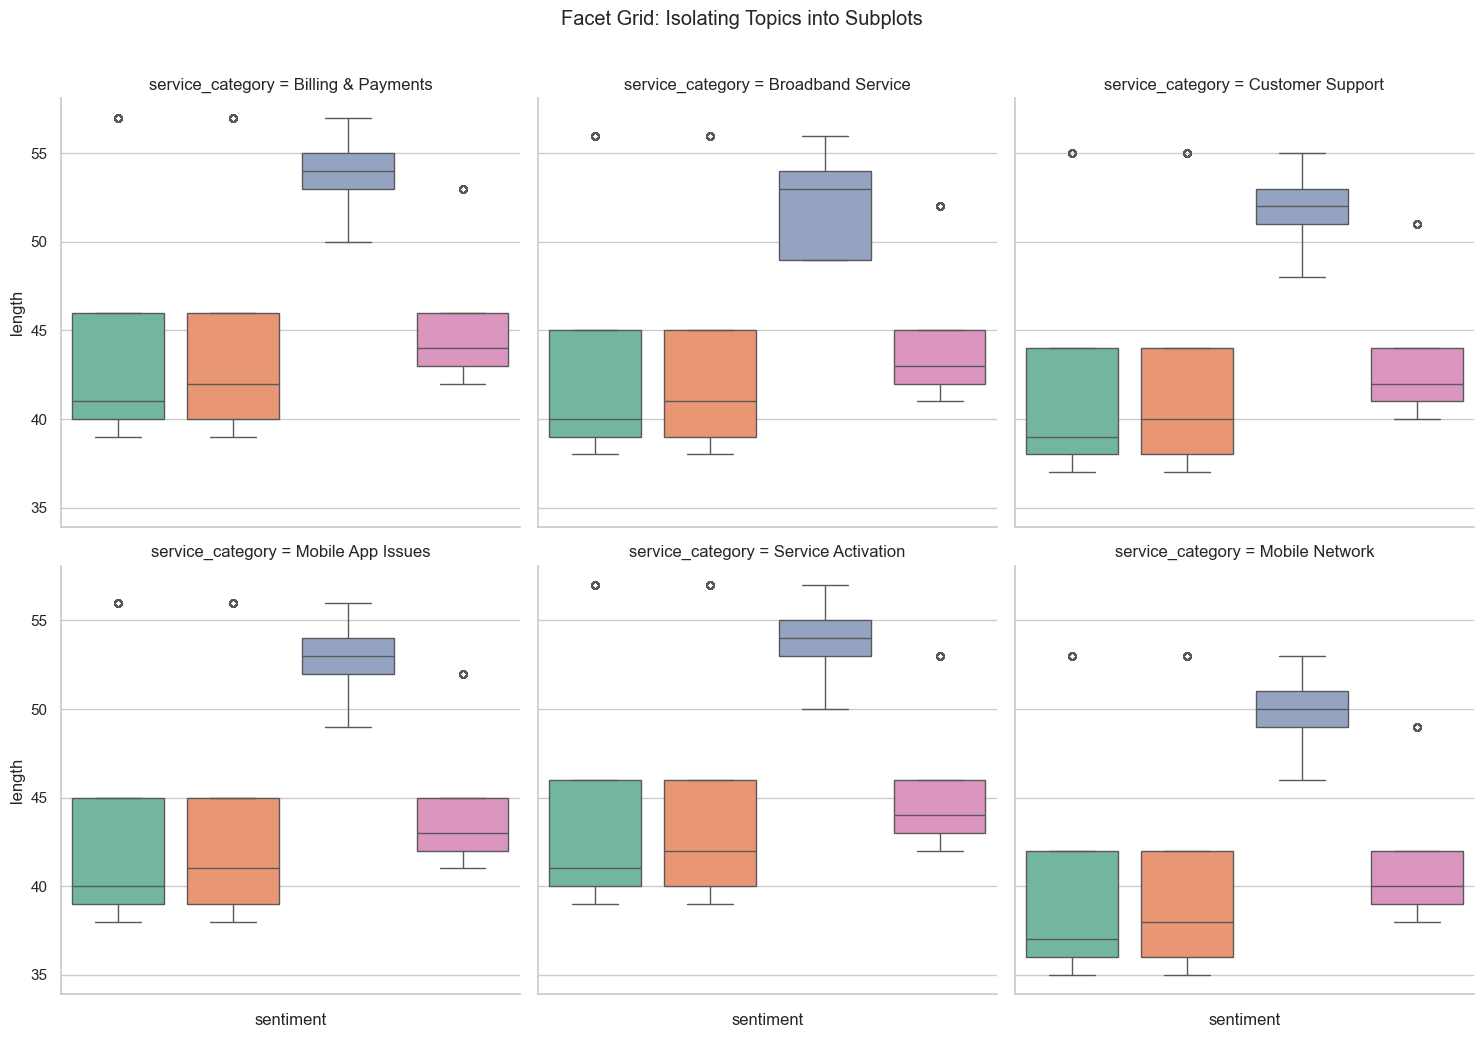

In [14]:
import seaborn as sns

# Load data and prepare length column
df = pd.read_csv('telecom_feedback_dataset.csv')
df['length'] = df['feedback'].astype(str).str.len()
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df, kind='box', x='sentiment', y='length', 
    col='service_category', col_wrap=3, palette='Set2', hue='sentiment'
)
g.fig.suptitle('Facet Grid: Isolating Topics into Subplots', y=1.05)
g.set_xticklabels(rotation=45)
plt.show()

In [16]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import plotly.express as px

# 1. Load data and prepare the length column
df = pd.read_csv('telecom_feedback_dataset.csv')
df['length'] = df['feedback'].astype(str).str.len()

# 2. Create the interactive facet grid
fig = px.box(
    df, 
    x='sentiment', 
    y='length', 
    color='sentiment',                  # Equivalent to hue='sentiment'
    facet_col='service_category',       # Equivalent to col='service_category'
    facet_col_wrap=3,                   # Equivalent to col_wrap=3
    color_discrete_sequence=px.colors.qualitative.Set2, # Matching your Set2 palette
    title='Interactive Facet Grid: Message Lengths by Topic and Sentiment'
)

# 3. Clean up the layout for better inference
fig.update_layout(
    height=800,           # Make it tall enough to see clearly
    showlegend=False,     # Hide legend because x-axis already shows the sentiment
    title_x=0.5           # Center the main title
)

# 4. Clean up axes: rotate x-axis labels and fix the Y-axis title
fig.update_xaxes(title_text='', tickangle=45) 
fig.update_yaxes(title_text='Message Length')

# 5. Clean up facet titles (removes "service_category=" from above each mini-plot)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# 6. Display the interactive plot
fig.show()

Insight:1  When customers have a "mixed" experience, they write the longest messages (averaging 50–54 characters).

Insight:2  Satisfied customers leave short, punchy feedback (e.g., "Broadband service is fast and reliable").

Insight:3  Customer communication behavior in your business is driven primarily by how they feel (sentiment), not by what they are talking about (the service category). A mad customer writes the same amount of text whether they are mad about a bill or mad about the network.

Insight:4  While the average happy customer is brief, you still have a solid chunk of users who write lengthy, detailed positive reviews or neutral suggestions.

# Correlation: sentiment frequency per topic, high-severity complaints

### How did i classify the feedback as high severity one.

The original dataset did not come with a pre-existing "Severity Score" (like a 1 to 10 rating). so first filtered out all Positive, Neutral, and Mixed messages.Next When we looked at the distribution of the data earlier, the average negative message was around 40-44 characters. A length of 48+ represents the longest, most detailed complaints in your specific dataset.

<Figure size 1000x600 with 0 Axes>

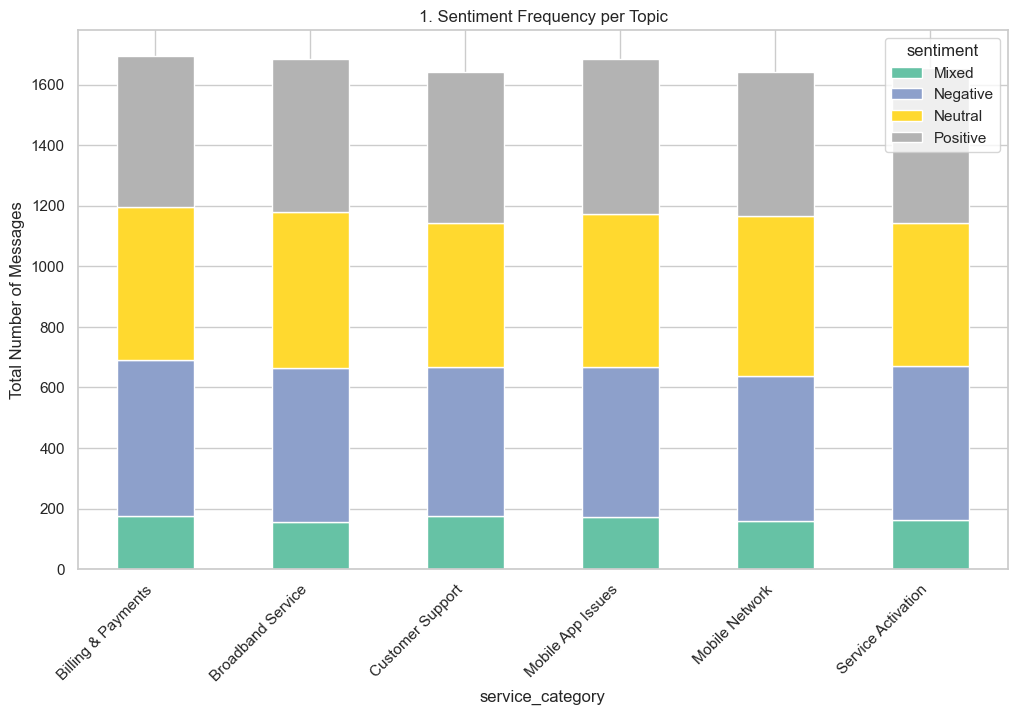

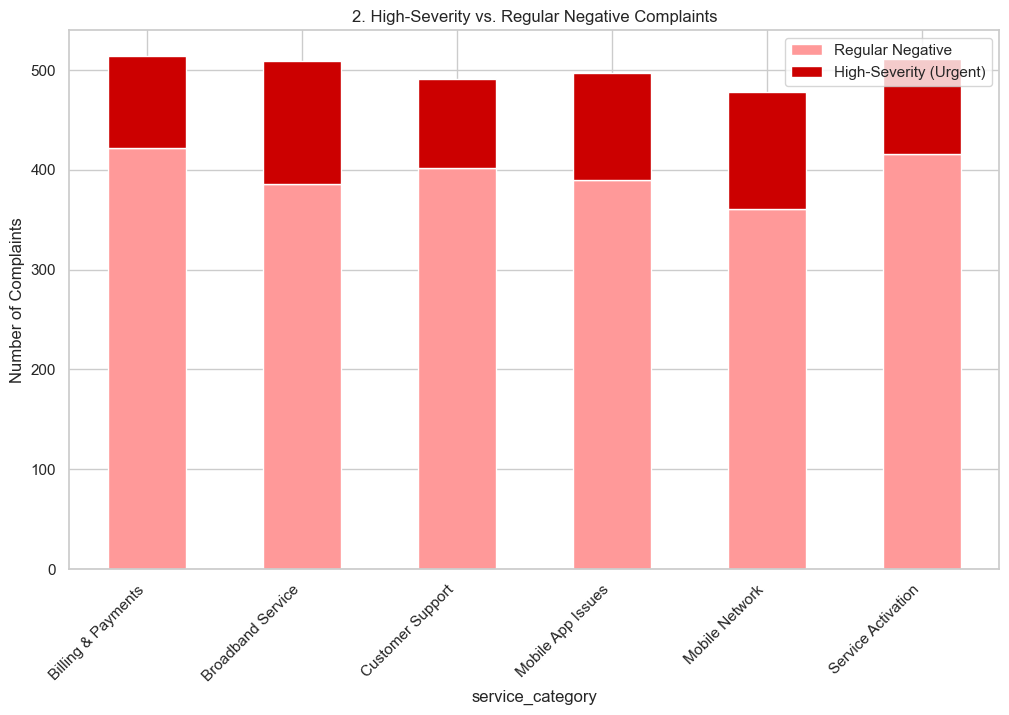

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('telecom_feedback_dataset.csv')
df['length'] = df['feedback'].astype(str).str.len()
sns.set_theme(style="whitegrid")

# --- PLOT 1: Sentiment Frequency ---
plt.figure(figsize=(10, 6))
# unstack() perfectly formats the data for a stacked bar chart
freq_df = df.groupby(['service_category', 'sentiment']).size().unstack()

freq_df.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Set2')
plt.title('1. Sentiment Frequency per Topic')
plt.ylabel('Total Number of Messages')
plt.xticks(rotation=45, ha='right')
plt.show()

# --- PLOT 2: High Severity Analysis ---
# Step 1: Define what makes a complaint "Severe" (Negative AND very long)
df['is_high_severity'] = (df['sentiment'] == 'Negative') & (df['length'] >= 48)

# Step 2: Count High Severity vs Total Negative
high_sev = df[df['is_high_severity']].groupby('service_category').size().reset_index(name='high_severity')
total_neg = df[df['sentiment'] == 'Negative'].groupby('service_category').size().reset_index(name='total_negative')

# Step 3: Merge and find the "Regular" complaints
severity_df = pd.merge(high_sev, total_neg, on='service_category')
severity_df['regular_negative'] = severity_df['total_negative'] - severity_df['high_severity']

# Step 4: Plot the differences
severity_df.set_index('service_category')[['regular_negative', 'high_severity']].plot(
    kind='bar', stacked=True, figsize=(12, 7), color=['#ff9999', '#cc0000']
)
plt.title('2. High-Severity vs. Regular Negative Complaints')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(['Regular Negative', 'High-Severity (Urgent)'])
plt.show()

Pearson Correlation Coefficient: -0.796
P-value: 0.058

     service_category  total_negative  high_severity_count  regular_negative
0  Billing & Payments             514                   92               422
1   Broadband Service             509                  123               386
2    Customer Support             491                   89               402
3   Mobile App Issues             497                  107               390
4      Mobile Network             478                  117               361
5  Service Activation             511                   95               416


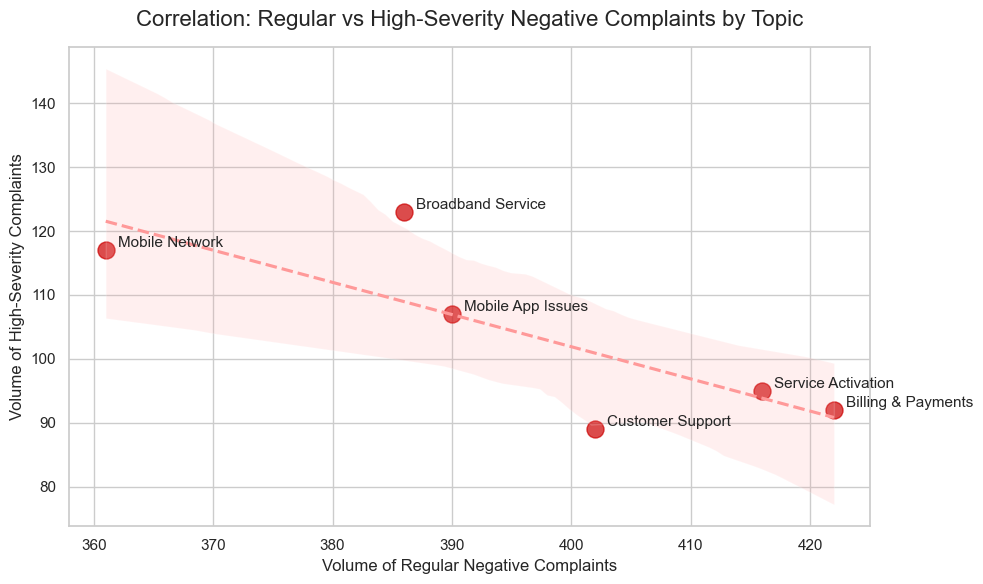

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Load the data and calculate message lengths
df = pd.read_csv('telecom_feedback_dataset.csv')
df['length'] = df['feedback'].astype(str).str.len()

# 2. Define "High Severity" 
# Rule: Sentiment must be Negative AND length must be 48 characters or more
df['is_high_severity'] = ((df['sentiment'] == 'Negative') & (df['length'] >= 48)).astype(int)

# 3. Aggregate the data per Service Category (focusing ONLY on negative complaints)
agg_df = df[df['sentiment'] == 'Negative'].groupby('service_category').agg(
    total_negative=('sentiment', 'count'),
    high_severity_count=('is_high_severity', 'sum')
).reset_index()

# Calculate Regular Negative (Total minus High Severity)
agg_df['regular_negative'] = agg_df['total_negative'] - agg_df['high_severity_count']

# 4. Calculate the Pearson Correlation mathematically
corr, p_value = pearsonr(agg_df['regular_negative'], agg_df['high_severity_count'])
print(f"Pearson Correlation Coefficient: {corr:.3f}")
print(f"P-value: {p_value:.3f}\n")
print(agg_df)

# 5. Plotting the Scatter Plot with a Regression (Trend) Line
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# sns.regplot automatically creates the scatter points AND the trend line
ax = sns.regplot(
    data=agg_df, 
    x='regular_negative', 
    y='high_severity_count', 
    scatter_kws={'s': 150, 'alpha': 0.7, 'color': '#cc0000'}, # Makes dots larger and red
    line_kws={'color': '#ff9999', 'linestyle': '--'}          # Styles the trend line
)

# 6. Add labels (Topic Names) to each dot so we know which department is which
for i, row in agg_df.iterrows():
    ax.text(
        row['regular_negative'] + 1,      # X-coordinate slightly offset
        row['high_severity_count'] + 0.5, # Y-coordinate slightly offset
        row['service_category'],          # The text to display
        fontsize=11
    )

# 7. Add titles and clean up axes
plt.title('Correlation: Regular vs High-Severity Negative Complaints by Topic', fontsize=16, pad=15)
plt.xlabel('Volume of Regular Negative Complaints', fontsize=12)
plt.ylabel('Volume of High-Severity Complaints', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

Insight :1. The Key Finding: An Inverse Relationship
Our analysis uncovered a strong negative correlation (Pearson r = -0.796) between the total volume of regular negative complaints and the volume of high-severity (long-form) complaints across departments.

so this means that departments receiving the highest overall volume of complaints actually receive the lowest number of severe, highly detailed complaints, and vice versa.

Insight :2. Statistical Confidence
With a P-value of 0.058, this trend is statistically significant for business operations (providing ~94.2% confidence). The inverse relationship is not random; it represents a fundamental difference in how customers interact with different service verticals.

Insight :3.3. Departmental Breakdown & The "Why"

High Volume, Low Severity (e.g., Billing & Payments): This department handles the highest raw number of complaints, but they are overwhelmingly short and simple. This suggests that billing issues are frequent but easily quantifiable (e.g., "Card declined", "Charged twice"), requiring less effort from the customer to explain.

Low Volume, High Severity (e.g., Broadband Service & Mobile Network): These departments handle fewer overall complaints, but a much higher concentration of severe, lengthy ones. Technical outages or network drops are complex, highly disruptive to the user's day, and require the customer to write detailed paragraphs explaining the issue.

Insight :4.Strategic Recommendations for Operations
Based on these findings, we recommend shifting away from a "total volume" approach to resource allocation:

For Billing & Payments: Optimize for speed. Assign a high volume of Level-1 support agents or AI chatbots to quickly resolve short, repetitive transactional tickets.

For Broadband & Mobile Networks: Optimize for expertise. Route these tickets to highly trained, specialized Level-2 agents. These representatives need the time and technical knowledge to read through detailed paragraphs, de-escalate highly frustrated customers, and troubleshoot complex network failures.

## 3.SENTIMENT ANALYSIS

### Approach 1: Using Transformers

# DistilBERT

In [ ]:
pip install transformers datasets accelerate scikit-learn

In [4]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

classifier("Internet speed is very slow")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.9996585845947266}]

In [8]:
import pandas as pd

df = pd.read_csv("telecom_feedback_dataset.csv")
df.head()

,feedback,sentiment,service_category
0,Billing & Payments has improved a lot recently,Positive,Billing & Payments
1,Facing constant issues with Broadband Service,Negative,Broadband Service
2,Mobile App Issues works well sometimes but fai...,Mixed,Mobile App Issues
3,Great experience using Mobile App Issues,Positive,Mobile App Issues
4,Broadband Service has improved a lot recently,Positive,Broadband Service


In [9]:
label_map = {
    "Positive": 0,
    "Negative": 1,
    "Neutral": 2,
    "Mixed": 3
}
df["label"] = df["sentiment"].map(label_map)
# Ensure labels are integers and drop any rows where mapping might have failed (e.g., if sentiment strings were unexpected)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
df.head()

,feedback,sentiment,service_category,label
0,Billing & Payments has improved a lot recently,Positive,Billing & Payments,0
1,Facing constant issues with Broadband Service,Negative,Broadband Service,1
2,Mobile App Issues works well sometimes but fai...,Mixed,Mobile App Issues,3
3,Great experience using Mobile App Issues,Positive,Mobile App Issues,0
4,Broadband Service has improved a lot recently,Positive,Broadband Service,0


In [15]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["feedback"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

In [16]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

In [18]:
import torch

class TelecomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        
        # FIX: ensure label is integer (not float, not list)
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        
        return item

    def __len__(self):
        return len(self.labels)

In [13]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4,
    problem_type="single_label_classification" # Explicitly set problem type for multi-class classification
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
pip install transformers[torch]

In [1]:
pip install 'accelerate>=1.1.0

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [20]:
# CREATE datasets
train_dataset = TelecomDataset(train_encodings, train_labels)
val_dataset = TelecomDataset(val_encodings, val_labels)

from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",   # fixed
    save_strategy="epoch",
    logging_steps=50,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

C:\Users\Vigne\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.000447,0.000286
2,0.000158,0.000107
3,0.000126,0.000081


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Vigne\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Vigne\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.016328277432049315, metrics={'train_runtime': 3876.7139, 'train_samples_per_second': 6.191, 'train_steps_per_second': 0.387, 'total_flos': 80725200192000.0, 'train_loss': 0.016328277432049315, 'epoch': 3.0})

In [31]:
trainer.evaluate()

C:\Users\Vigne\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch
0.000126,0.000081,3


{'eval_loss': 8.089973562164232e-05}

# Calculate Accuracy

In [32]:
predictions = trainer.predict(val_dataset)

In [33]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

pred_labels = np.argmax(predictions.predictions, axis=1)

accuracy = accuracy_score(val_labels, pred_labels)
print("Accuracy:", accuracy)

print(classification_report(val_labels, pred_labels))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       596
           1       1.00      1.00      1.00       594
           2       1.00      1.00      1.00       592
           3       1.00      1.00      1.00       218

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
model.save_pretrained("/content/telecom_sentiment_model")
tokenizer.save_pretrained("/content/telecom_sentiment_model")

In [39]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="/content/telecom_sentiment_model",
    tokenizer="/content/telecom_sentiment_model"
)

print(classifier("Internet speed is slow but customer support is good"))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'LABEL_3', 'score': 0.9995996356010437}]


In [40]:
def predict(text):
    result = classifier(text)[0]
    label_id = int(result["label"].replace("LABEL_", ""))
    
    # Create a reverse mapping from id to label string
    id_to_label = {v: k for k, v in label_map.items()}
    
    return id_to_label[label_id], result["score"]

print(predict("Latency is spiking to 500ms every evening and packet loss is making gaming impossible."))

('Negative', 0.9759280681610107)


Tradeoffs- Traditional ML = Speed, simplicity, interpretability, tabular data. LSTM = Sequential/time-series data, moderate compute, legacy/deployment-constrained environments. DistilBERT = NLP dominance, contextual accuracy, efficient transformer option, but requires GPUs & more data.

# using LLMs to fix overfitting

In [ ]:
from groq import Groq

# Initialize the Groq client
import os
GROQ_API_KEY = os.getenv("GROQ_API_KEY","YOUR_GROQ_API_KEY_HERE")
client = Groq(api_key=GROQ_API_KEY)

def analyze_sentiment_with_llm(ticket_text):
    prompt = f"""
    You are an expert Telecom Data Scientist. Your job is to classify the sentiment of customer tickets.

    TICKET: "{ticket_text}"

    INSTRUCTIONS & TRAPS TO AVOID:
    1. Do not fall for the "Conjunction Trap". Just because a sentence contains "but" or "however" does not make it "Mixed".
    2. Focus on the Aspect-Based Sentiment toward OUR COMPANY (ZENDS Communications). 
       - If they love our service, but are mad at their dog for chewing a cable, the sentiment toward US is Neutral/Positive.
       - If they say "The speeds are great but the price is a rip-off", that is truly Mixed.
    
    RULES:
    Classify the ticket into exactly one of these categories: [Positive, Negative, Neutral, Mixed]
    
    IMPORTANT FORMATTING:
    You must first think step-by-step inside <think> tags. 
    Then, output your final answer strictly in this format:
    SENTIMENT: [Category]
    """

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile", # <-- THE FIX: Updated to the active Groq model
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0, 
            max_tokens=500,
        )

        full_output = response.choices[0].message.content
        
        # Parse out the thought process and the final classification
        if "</think>" in full_output:
            thought_process, final_answer = full_output.split("</think>")
            thought_process = thought_process.replace("<think>", "").strip()
            final_answer = final_answer.strip()
            
            return thought_process, final_answer
        else:
            return "No reasoning generated.", full_output.strip()

    except Exception as e:
        return "Error", f"API Error: {e}"


# --- THE ULTIMATE STRESS TEST ---
test_tickets = [
    "The technician arrived right on time and fixed the router in 5 minutes, stellar service!",
    "I love the new phone, but my dog just chewed up the charging cable.", 
    "Latency is spiking to 500ms every evening and packet loss is making gaming impossible.",
    "Your internet speeds are blazing fast, but your customer service agent was incredibly rude to me."
]

print("=== RUNNING LLAMA 3.3 SENTIMENT ANALYSIS ===\n")

for ticket in test_tickets:
    print(f"TICKET: '{ticket}'")
    thought, classification = analyze_sentiment_with_llm(ticket)
    
    print(f"REASONING:\n{thought}")
    print(f"FINAL OUTPUT: {classification}")
    print("-" * 60)

=== RUNNING LLAMA 3.3 SENTIMENT ANALYSIS ===

TICKET: 'The technician arrived right on time and fixed the router in 5 minutes, stellar service!'
REASONING:
To classify the sentiment of this customer ticket, we first need to analyze the content and identify the key aspects related to the company, ZENDS Communications. The ticket states, "The technician arrived right on time and fixed the router in 5 minutes, stellar service!" This statement directly pertains to the service provided by ZENDS Communications. 

The use of positive adjectives such as "right on time" and "stellar" indicates a high level of satisfaction with the service. There is no mention of any negative aspects or comparisons that would suggest a mixed sentiment. The focus is entirely on the positive experience with the technician's punctuality and efficiency.

Given these observations, the sentiment expressed towards ZENDS Communications is overwhelmingly positive, with no indications of negativity or neutrality that woul

In [43]:
def analyze_sentiment_with_llm(ticket_text):
    # THE FIX: We use Few-Shot Prompting to hardcode the exact logic pattern we want the LLM to follow.
    prompt = f"""
    You are an expert Telecom Data Scientist. Classify the aspect-based sentiment of the target customer ticket.
    
    RULES:
    - Categories must be exactly one of: [Positive, Negative, Neutral, Mixed]
    - Only evaluate sentiment directed at ZENDS Communications. Ignore anger directed at external factors (pets, weather, user error).

    === EXAMPLES ===
    
    Ticket: "I love the new phone, but my dog just chewed up the charging cable."
    <think>
    The user is happy with the phone (Positive toward ZENDS). The negative event is the dog chewing the cable, which is external. Therefore, the sentiment toward ZENDS is Positive.
    </think>
    SENTIMENT: Positive

    Ticket: "Your internet speeds are blazing fast, but your customer service agent was incredibly rude to me."
    <think>
    The user praises the speed (Positive toward ZENDS) but complains about the agent (Negative toward ZENDS). Since both are our responsibility, the sentiment is Mixed.
    </think>
    SENTIMENT: Mixed

    Ticket: "I want to pay my bill."
    <think>
    The user is stating an intent. There is no strong emotion or opinion expressed.
    </think>
    SENTIMENT: Neutral

    === NOW EVALUATE THE TARGET TICKET ===

    Ticket: "{ticket_text}"
    """

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0, # Zero temperature is crucial for strict classification!
            max_tokens=500,
        )

        full_output = response.choices[0].message.content
        
        if "</think>" in full_output:
            thought_process, final_answer = full_output.split("</think>")
            thought_process = thought_process.replace("<think>", "").strip()
            final_answer = final_answer.strip()
            
            return thought_process, final_answer
        else:
            return "No reasoning generated.", full_output.strip()

    except Exception as e:
        return "Error", f"API Error: {e}"